In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

import os
import shutil
import random
import hashlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/34 no.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/N20.JPG
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/N1.JPG
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/49 no.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/N15.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/No18.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/31 no.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/no 6.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/3 no.jpg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/no 5.jpeg
/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/no 1.jpg
/kaggle/input/datasets/navoneel/brain-mri-i

2026-06-15 12:48:03.232862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781527683.612405      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781527683.722998      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781527684.713726      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781527684.713780      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781527684.713783      58 computation_placer.cc:177] computation placer alr

In [2]:

#Copy Dataset to Working Directory
SOURCE_DIR = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection"

WORK_DATASET = "/kaggle/working/brain_dataset"

shutil.copytree(
    SOURCE_DIR,
    WORK_DATASET,
    dirs_exist_ok=True
)

work_dir = "/kaggle/working/brain_split"

In [3]:
#imporing data

YES_DIR = os.path.join(WORK_DATASET, "yes")
NO_DIR = os.path.join(WORK_DATASET, "no")

print(YES_DIR)
print(NO_DIR)


/kaggle/working/brain_dataset/yes
/kaggle/working/brain_dataset/no


In [4]:
#Checking Class Distribution

yes_count = len(os.listdir(YES_DIR))
no_count = len(os.listdir(NO_DIR))

print("Tumor:", yes_count)
print("No Tumor:", no_count)

Tumor: 155
No Tumor: 98


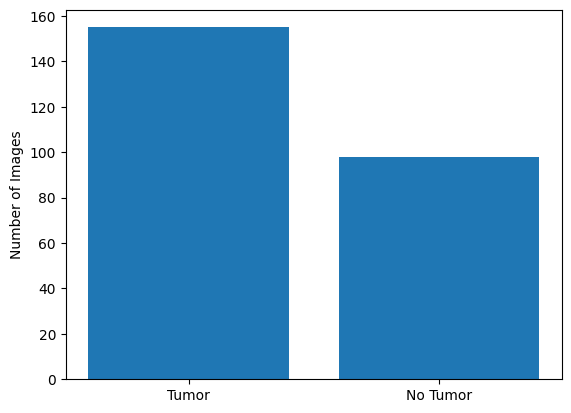

In [5]:
#Ploting the Class Distribution

plt.bar(['Tumor', 'No Tumor'],
        [yes_count, no_count])

plt.ylabel('Number of Images')
plt.show()

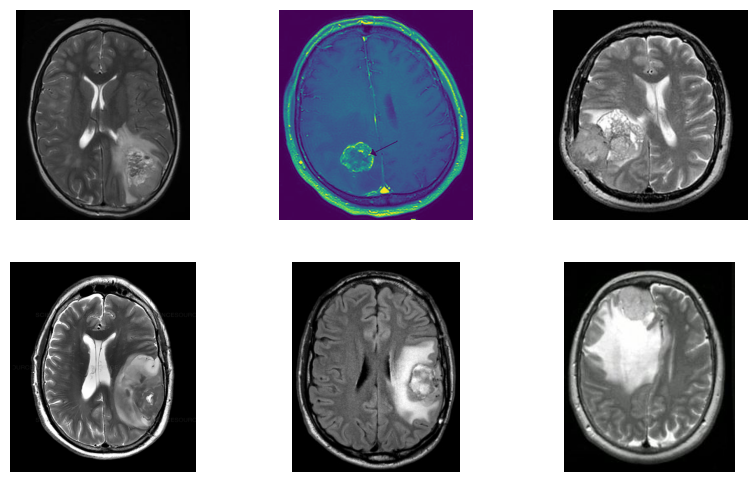

In [6]:
#Visualize Random Images

files = random.sample(
    os.listdir(YES_DIR),
    6
)

plt.figure(figsize=(10,6))

for i, file in enumerate(files):

    img = Image.open(
        os.path.join(YES_DIR, file)
    )

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

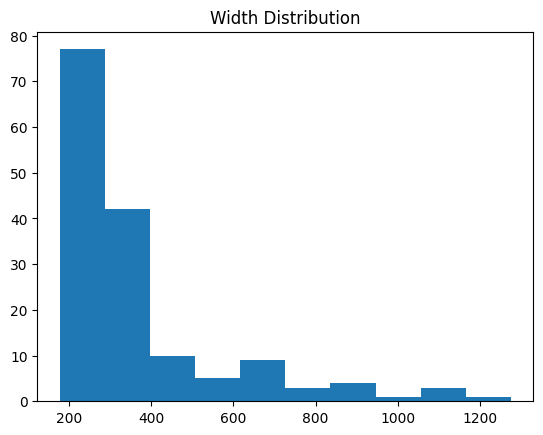

In [7]:
#Image Dimension Distribution
widths = []
heights = []

for file in os.listdir(YES_DIR):

    img = Image.open(
        os.path.join(YES_DIR, file)
    )

    widths.append(img.size[0])
    heights.append(img.size[1])

plt.hist(widths)
plt.title("Width Distribution")
plt.show()

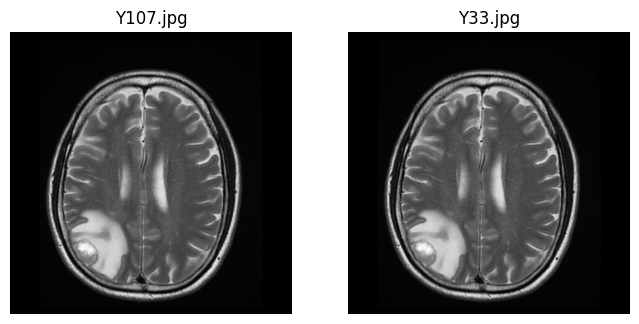

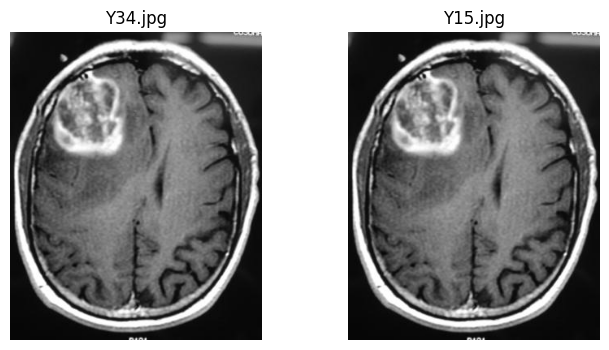

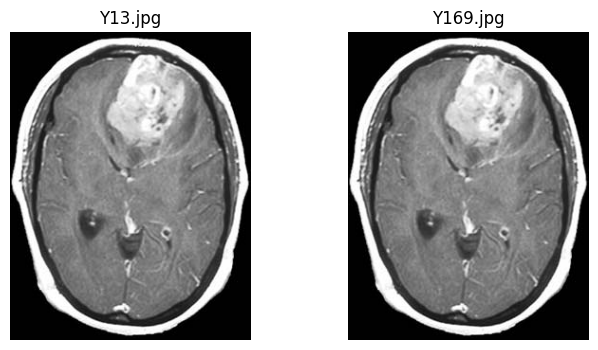

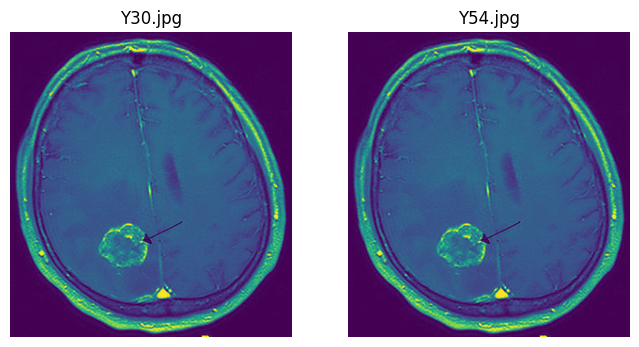

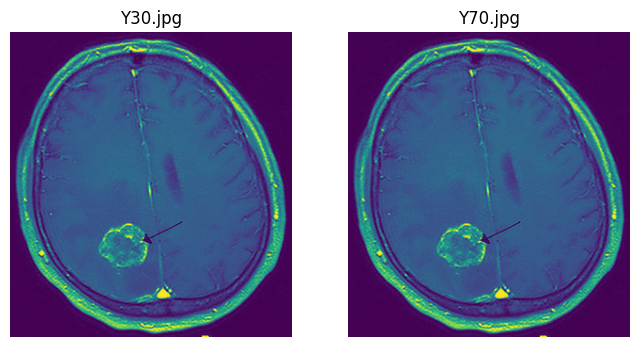

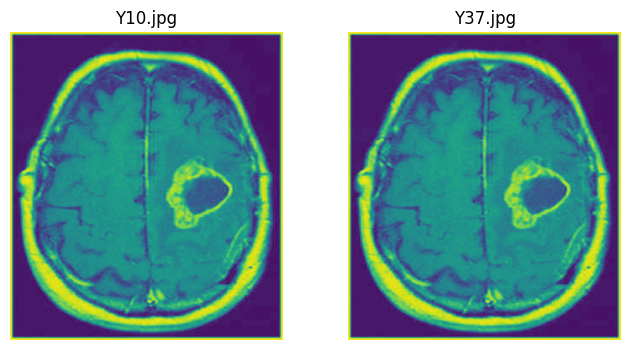

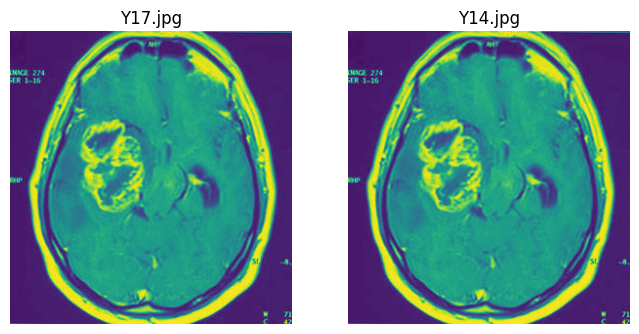

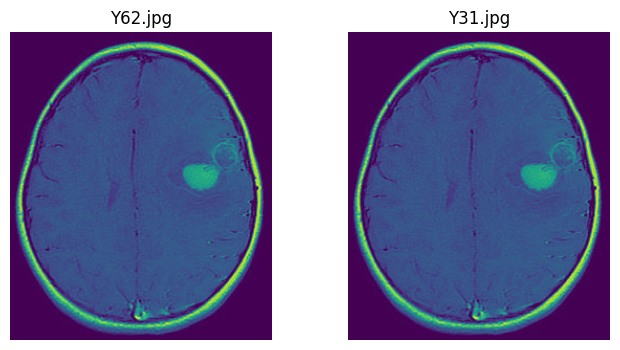

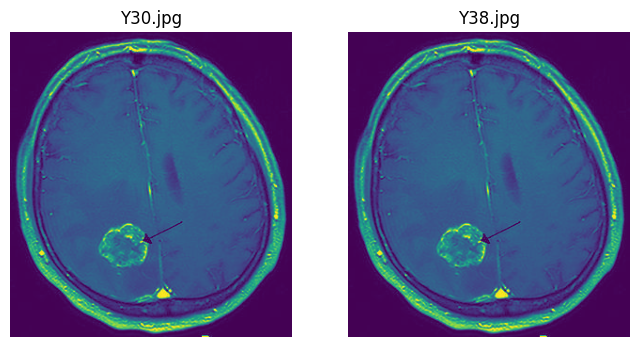

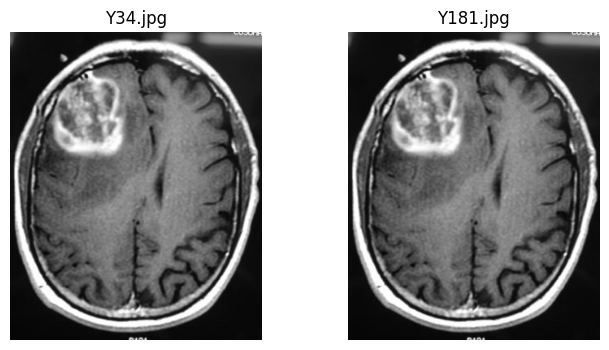

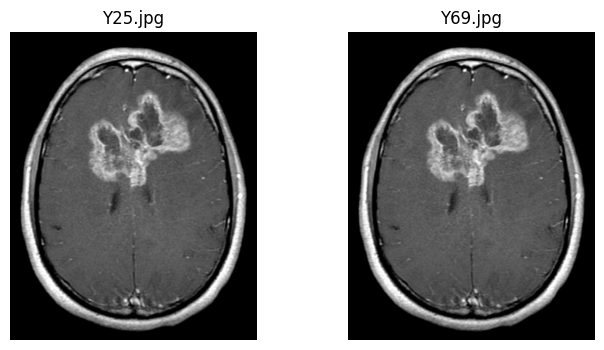

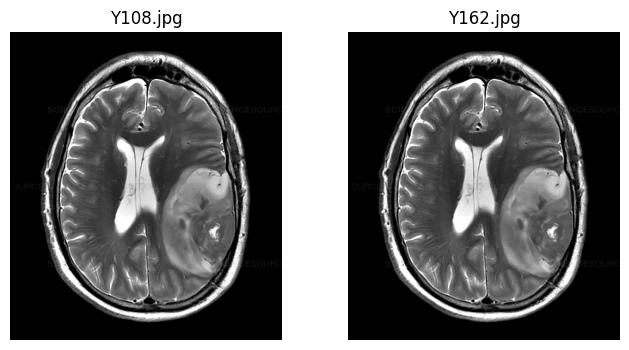

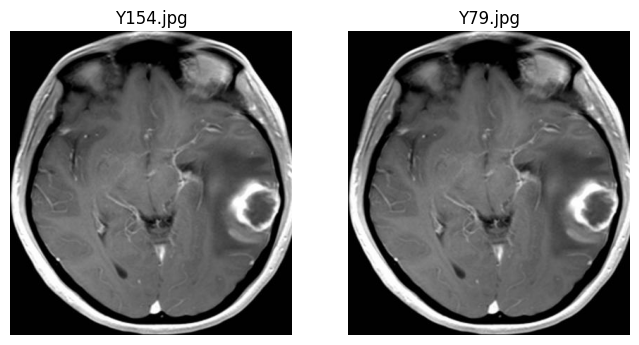

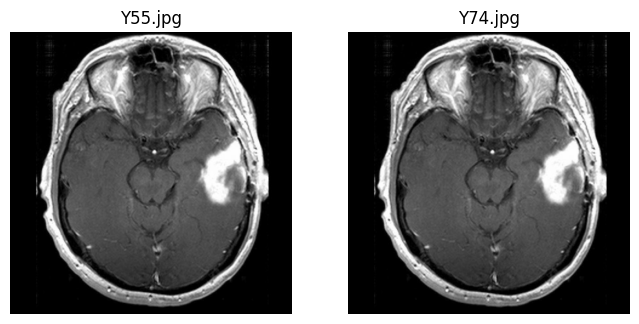

In [8]:
#Check the Duplicates in YES
hash_dict = {}

for file in os.listdir(YES_DIR):

    path = os.path.join(YES_DIR, file)

    with open(path, 'rb') as f:

        h = hashlib.md5(f.read()).hexdigest()

    if h in hash_dict:

        original = hash_dict[h]

        img1 = Image.open(
            os.path.join(YES_DIR, original)
        )

        img2 = Image.open(path)

        plt.figure(figsize=(8,4))

        plt.subplot(1,2,1)
        plt.imshow(img1)
        plt.title(original)
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.imshow(img2)
        plt.title(file)
        plt.axis('off')

        plt.show()

    else:
        hash_dict[h] = file

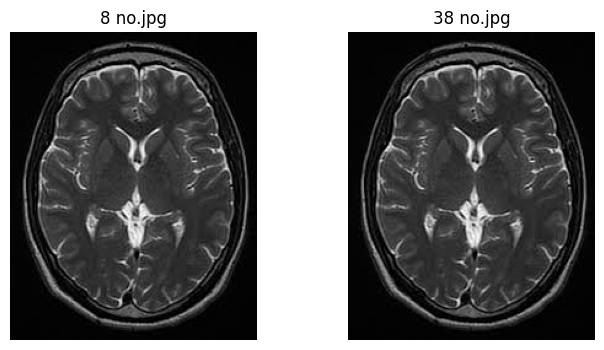

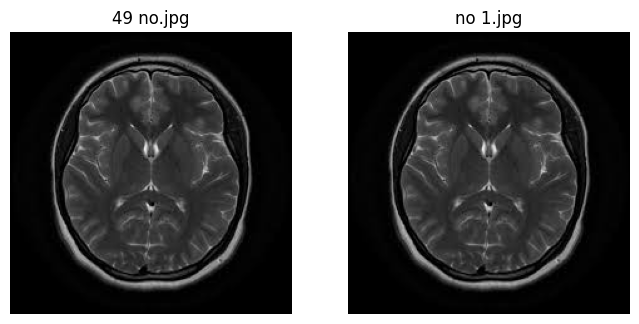

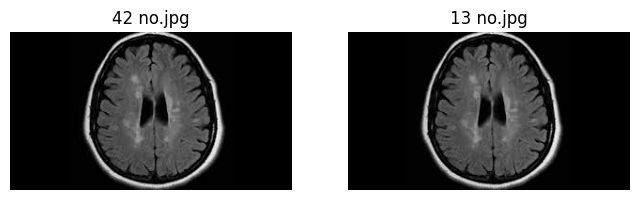

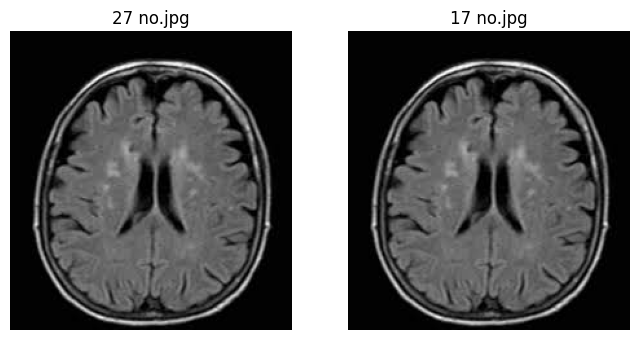

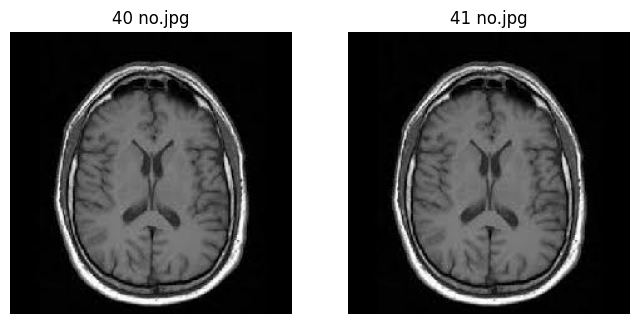

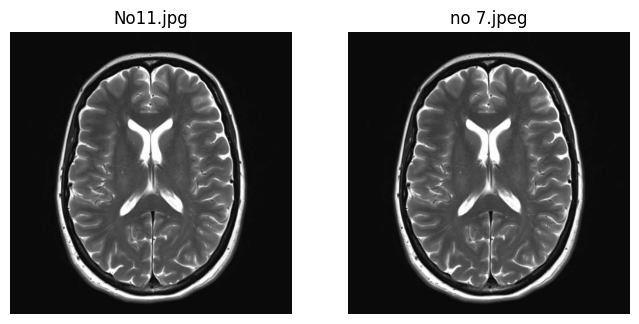

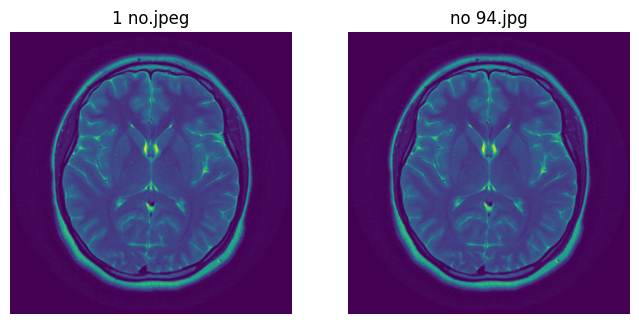

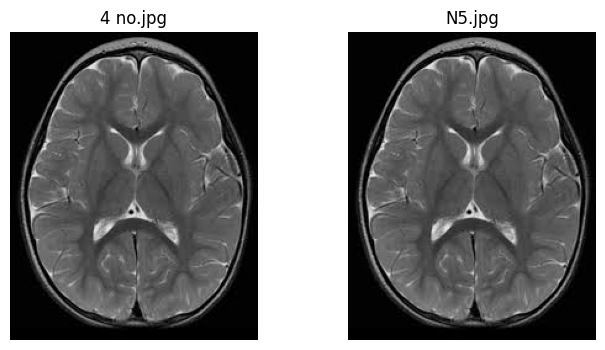

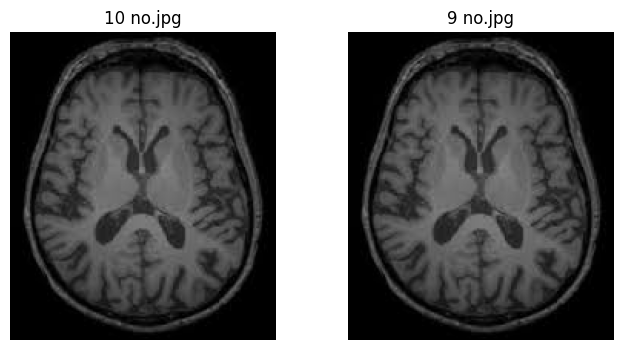

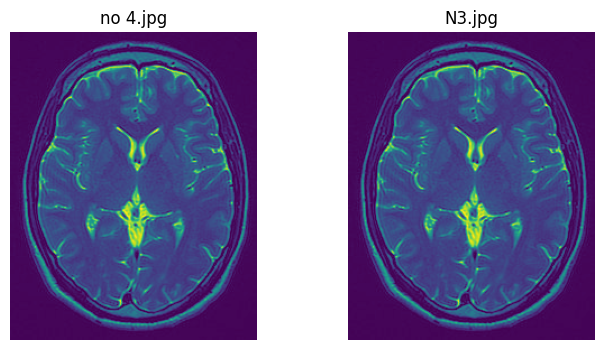

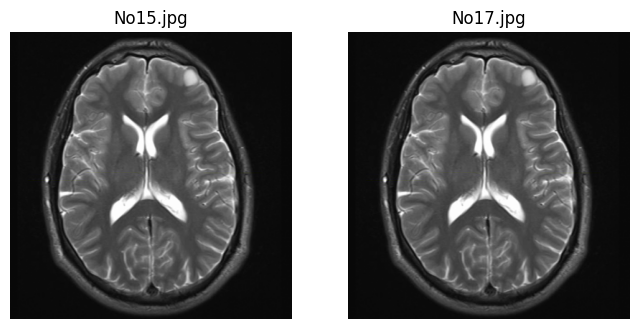

In [9]:
#Check the Duplicates in NO

hash_dict = {}

for file in os.listdir(NO_DIR):

    path = os.path.join(NO_DIR, file)

    with open(path, 'rb') as f:

        h = hashlib.md5(f.read()).hexdigest()

    if h in hash_dict:

        original = hash_dict[h]

        img1 = Image.open(
            os.path.join(NO_DIR, original)
        )

        img2 = Image.open(path)

        plt.figure(figsize=(8,4))

        plt.subplot(1,2,1)
        plt.imshow(img1)
        plt.title(original)
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.imshow(img2)
        plt.title(file)
        plt.axis('off')

        plt.show()

    else:
        hash_dict[h] = file

In [10]:
#Removing Duplicates from YES
hashes = set()

for file in os.listdir(YES_DIR):

    path = os.path.join(YES_DIR, file)

    with open(path, 'rb') as f:
        file_hash = hashlib.md5(
            f.read()
        ).hexdigest()

    if file_hash in hashes:
        print("Removing duplicate:", file)
        os.remove(path)

    else:
        hashes.add(file_hash)

Removing duplicate: Y33.jpg
Removing duplicate: Y15.jpg
Removing duplicate: Y169.jpg
Removing duplicate: Y54.jpg
Removing duplicate: Y70.jpg
Removing duplicate: Y37.jpg
Removing duplicate: Y14.jpg
Removing duplicate: Y31.jpg
Removing duplicate: Y38.jpg
Removing duplicate: Y181.jpg
Removing duplicate: Y69.jpg
Removing duplicate: Y162.jpg
Removing duplicate: Y79.jpg
Removing duplicate: Y74.jpg


In [11]:
#Removing Duplicates from NO
hashes = set()

for file in os.listdir(NO_DIR):

    path = os.path.join(NO_DIR, file)

    with open(path, 'rb') as f:
        file_hash = hashlib.md5(
            f.read()
        ).hexdigest()

    if file_hash in hashes:
        print("Removing duplicate:", file)
        os.remove(path)

    else:
        hashes.add(file_hash)

Removing duplicate: 38 no.jpg
Removing duplicate: no 1.jpg
Removing duplicate: 13 no.jpg
Removing duplicate: 17 no.jpg
Removing duplicate: 41 no.jpg
Removing duplicate: no 7.jpeg
Removing duplicate: no 94.jpg
Removing duplicate: N5.jpg
Removing duplicate: 9 no.jpg
Removing duplicate: N3.jpg
Removing duplicate: No17.jpg


In [12]:
#Confirm the removal

print("Tumor images:",
      len(os.listdir(YES_DIR)))

print("No tumor images:",
      len(os.listdir(NO_DIR)))

Tumor images: 141
No tumor images: 87


In [13]:
# Creating folder paths for training and validation datasets

WORK_DIR = "/kaggle/working/brain_split"

# Path for training images belonging to the "yes" (tumor) class
train_yes = os.path.join(WORK_DIR, "train", "yes")

# Path for training images belonging to the "no" (non-tumor) class
train_no = os.path.join(WORK_DIR, "train", "no")

# Path for validation images belonging to the "yes" (tumor) class
val_yes = os.path.join(WORK_DIR, "validation", "yes")

# Path for validation images belonging to the "no" (non-tumor) class
val_no = os.path.join(WORK_DIR, "validation", "no")

# Create the directories if they do not already exist

for folder in [train_yes, train_no, val_yes, val_no]:

    # Create the directory.
    # exist_ok=True prevents an error if the folder already exists.
    os.makedirs(folder, exist_ok=True)

In [14]:
# seeding produces the same train-validation split every time.
random.seed(42)
# Obtain the list of image filenames from each class folder
# List all image files in the tumor ("yes") folder
yes_files = os.listdir(YES_DIR)

# List all image files in the non-tumor ("no") folder
no_files = os.listdir(NO_DIR)

# Randomly shuffle the filenames

random.shuffle(yes_files)
random.shuffle(no_files)

# Compute the split index for an 80:20 train-validation split
# Compute 80% of the total tumor images
yes_split = int(0.8 * len(yes_files))

# Compute 80% of the total non-tumor images
no_split = int(0.8 * len(no_files))

# Split tumor images into training and validation sets

# First 80% → training set
train_yes_files = yes_files[:yes_split]

# Remaining 20% → validation set
val_yes_files = yes_files[yes_split:]


# Split non-tumor images into training and validation sets

# First 80% → training set
train_no_files = no_files[:no_split]

# Remaining 20% → validation set
val_no_files = no_files[no_split:]

In [15]:
def copy_files(file_list, src_dir, dst_dir):
    for f in file_list:
        shutil.copy(
            os.path.join(src_dir, f),
            os.path.join(dst_dir, f)
        )

copy_files(train_yes_files, YES_DIR, train_yes)
copy_files(val_yes_files, YES_DIR, val_yes)

copy_files(train_no_files, NO_DIR, train_no)
copy_files(val_no_files, NO_DIR, val_no)

In [16]:
print("Train Yes:", len(os.listdir(train_yes)))
print("Train No :", len(os.listdir(train_no)))

print("Val Yes  :", len(os.listdir(val_yes)))
print("Val No   :", len(os.listdir(val_no)))

Train Yes: 112
Train No : 69
Val Yes  : 29
Val No   : 18


In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,

    zoom_range=0.10,

    horizontal_flip=True,

    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [18]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(WORK_DIR, "train"),
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    os.path.join(WORK_DIR, "validation"),
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 181 images belonging to 2 classes.
Found 47 images belonging to 2 classes.


In [19]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.3115942028985508), 1: np.float64(0.8080357142857143)}


In [20]:
print(train_generator.class_indices)

{'no': 0, 'yes': 1}


In [21]:
labels = train_generator.classes

print("No Tumor :", np.sum(labels == 0))
print("Tumor    :", np.sum(labels == 1))

No Tumor : 69
Tumor    : 112


In [22]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781527717.787320      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781527717.793528      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/30


I0000 00:00:1781527722.255044     143 service.cc:152] XLA service 0x7e1c18004f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781527722.255090     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781527722.255095     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781527722.790869     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-15 12:48:45.384948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-15 12:48:45.530265: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/12 ━━━━━━━━━━━━━━━━━━━━ 1:27 8s/step - accuracy: 0.5000 - loss: 0.7312

I0000 00:00:1781527728.118076     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 6/12 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.5005 - loss: 0.8735

2026-06-15 12:48:50.226880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-15 12:48:50.369588: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 639ms/step - accuracy: 0.5967 - loss: 0.7525 - val_accuracy: 0.7234 - val_loss: 0.5564
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.7348 - loss: 0.5792 - val_accuracy: 0.7447 - val_loss: 0.5390
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.7514 - loss: 0.5402 - val_accuracy: 0.7447 - val_loss: 0.5613
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.7348 - loss: 0.5639 - val_accuracy: 0.7447 - val_loss: 0.5118
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.7072 - loss: 0.5841 - val_accuracy: 0.7447 - val_loss: 0.5182
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.7624 - loss: 0.5693 - val_accuracy: 0.6809 - val_loss: 0.5935
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.7790 - loss: 0.5314 - val_accuracy: 0.6809 - val_loss: 0.5952
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.7569 - loss: 0.5587 - val_accuracy: 0.6596 - val

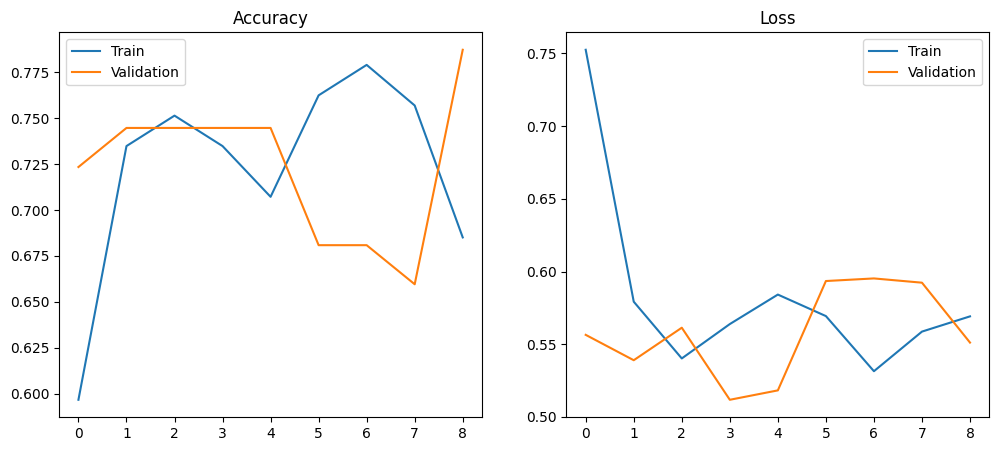

In [25]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title('Loss')

plt.show()

In [26]:
from sklearn.metrics import classification_report

y_true = validation_generator.classes

y_prob = model.predict(validation_generator)
y_pred = (y_prob > 0.5).astype(int).flatten()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=['No Tumor', 'Tumor']
    )
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step
              precision    recall  f1-score   support

    No Tumor       0.75      0.50      0.60        18
       Tumor       0.74      0.90      0.81        29

    accuracy                           0.74        47
   macro avg       0.75      0.70      0.71        47
weighted avg       0.75      0.74      0.73        47



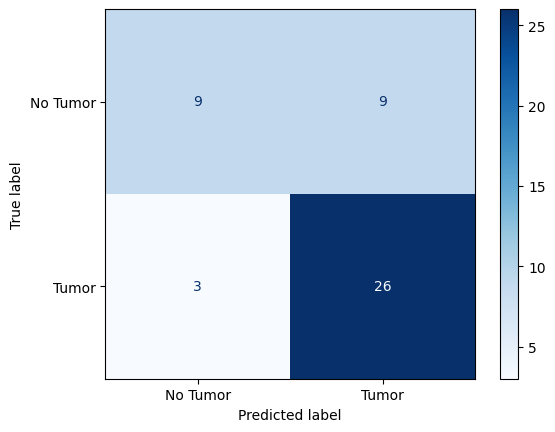

In [27]:
from sklearn.metrics import *
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Tumor', 'Tumor']
).plot(cmap='Blues')

plt.show()

In [28]:
import pickle

with open('/kaggle/working/history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [29]:
model.save('/kaggle/working/brain_tumor_model.keras')

In [30]:
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [31]:
train_datagen = ImageDataGenerator(

    preprocessing_function=
    tf.keras.applications.mobilenet_v2.preprocess_input,

    rotation_range=20,

    width_shift_range=0.15,
    height_shift_range=0.15,

    zoom_range=0.15,

    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(

    preprocessing_function=
    tf.keras.applications.mobilenet_v2.preprocess_input
)

In [32]:
train_generator = train_datagen.flow_from_directory(

    os.path.join(WORK_DIR, "train"),

    target_size=(224,224),

    batch_size=16,

    class_mode='binary',

    shuffle=True
)

Found 181 images belonging to 2 classes.


In [33]:
validation_generator = validation_datagen.flow_from_directory(

    os.path.join(WORK_DIR, "validation"),

    target_size=(224,224),

    batch_size=16,

    class_mode='binary',

    shuffle=False
)

Found 47 images belonging to 2 classes.


In [34]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.3115942028985508), 1: np.float64(0.8080357142857143)}


In [35]:
base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
base_model.trainable = False

In [37]:
model = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

In [38]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [40]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/30


2026-06-15 12:49:36.854120: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-15 12:49:36.990817: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 5/12 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.5094 - loss: 0.9261

2026-06-15 12:49:50.496351: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-15 12:49:50.637270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5820 - loss: 0.8289

2026-06-15 12:50:09.340535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-15 12:50:09.477195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.6354 - loss: 0.7080 - val_accuracy: 0.7021 - val_loss: 0.5960
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.7735 - loss: 0.4605 - val_accuracy: 0.6596 - val_loss: 0.5770
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.7901 - loss: 0.4274 - val_accuracy: 0.7234 - val_loss: 0.5192
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.8343 - loss: 0.3793 - val_accuracy: 0.7660 - val_loss: 0.4842
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.8398 - loss: 0.3601 - val_accuracy: 0.7660 - val_loss: 0.4992
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.8453 - loss: 0.3215 - val_accuracy: 0.8511 - val_loss: 0.4306
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.8177 - loss: 0.3937 - val_accuracy: 0.8723 - val_loss: 0.3781
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.8343 - loss: 0.3369 - val_accuracy: 0.8298 - val_lo

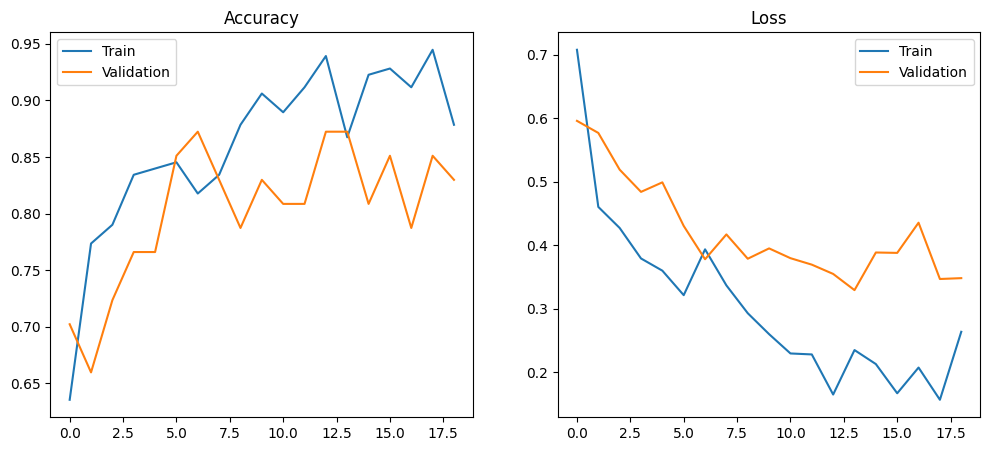

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")

plt.legend(['Train','Validation'])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [42]:
y_true = validation_generator.classes

y_prob = model.predict(validation_generator)

y_pred = (y_prob > 0.5).astype(int).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


In [43]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            'No Tumor',
            'Tumor'
        ]
    )
)

              precision    recall  f1-score   support

    No Tumor       0.88      0.78      0.82        18
       Tumor       0.87      0.93      0.90        29

    accuracy                           0.87        47
   macro avg       0.87      0.85      0.86        47
weighted avg       0.87      0.87      0.87        47



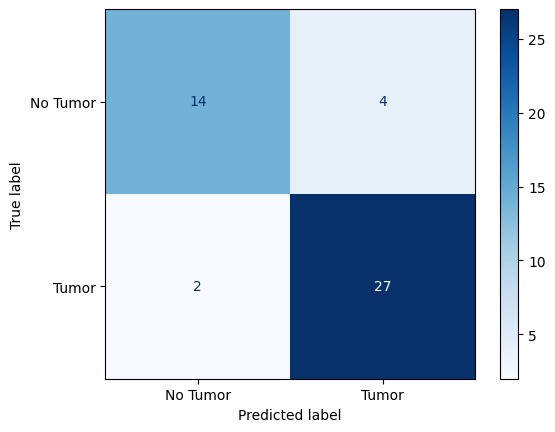

In [44]:
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Tumor', 'Tumor']
).plot(cmap='Blues')

plt.show()

In [45]:
model.save(
    "/kaggle/working/mobilenetv2_brain_tumor.keras"
)

In [46]:
base_model.trainable = True

In [47]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [48]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [49]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7127 - loss: 0.9365 - val_accuracy: 0.8723 - val_loss: 0.3286
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.7845 - loss: 0.6115 - val_accuracy: 0.8723 - val_loss: 0.3378
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.8122 - loss: 0.5433 - val_accuracy: 0.7872 - val_loss: 0.3604
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.8287 - loss: 0.5241 - val_accuracy: 0.8085 - val_loss: 0.3945


In [50]:
acc = history.history['accuracy'] + history_finetune.history['accuracy']

val_acc = (
    history.history['val_accuracy']
    + history_finetune.history['val_accuracy']
)

loss = (
    history.history['loss']
    + history_finetune.history['loss']
)

val_loss = (
    history.history['val_loss']
    + history_finetune.history['val_loss']
)

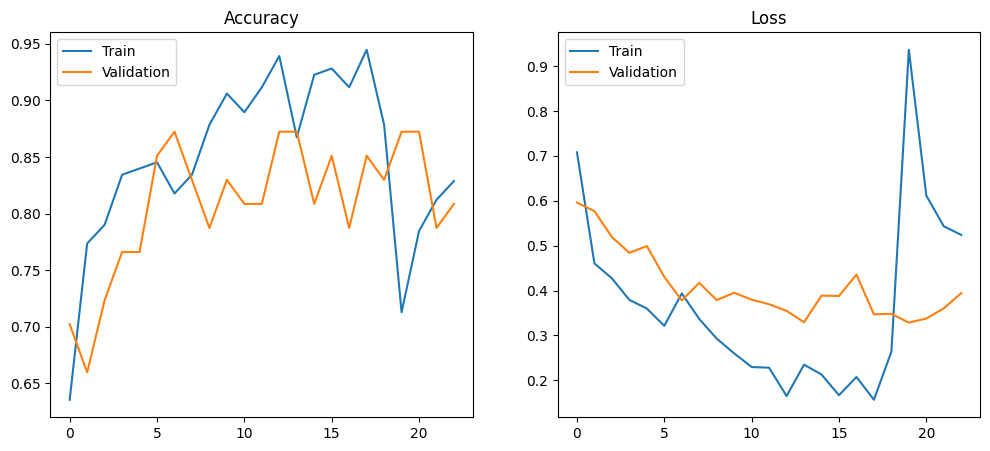

In [51]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc)
plt.plot(val_acc)
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(loss)
plt.plot(val_loss)
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [52]:
from sklearn.metrics import classification_report

y_true = validation_generator.classes

y_prob = model.predict(validation_generator)
y_pred = (y_prob > 0.5).astype(int).flatten()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=['No Tumor', 'Tumor']
    )
)

1/3 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7e1cef7a04a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
              precision    recall  f1-score   support

    No Tumor       0.88      0.78      0.82        18
       Tumor       0.87      0.93      0.90        29

    accuracy                           0.8

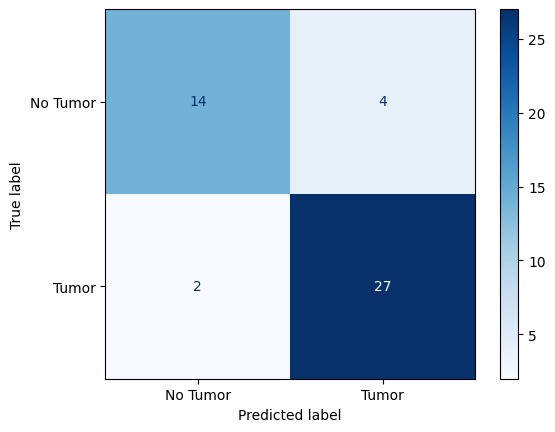

In [53]:
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Tumor', 'Tumor']
).plot(cmap='Blues')

plt.show()

In [54]:
model.save('/kaggle/working/brain_tumor_model_final.keras')

In [55]:
print(model.input_shape)

(None, 224, 224, 3)


Shape before preprocessing: (224, 224, 3)
Shape after preprocessing: (1, 224, 224, 3)


2026-06-15 12:52:48.085750: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-15 12:52:48.219473: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


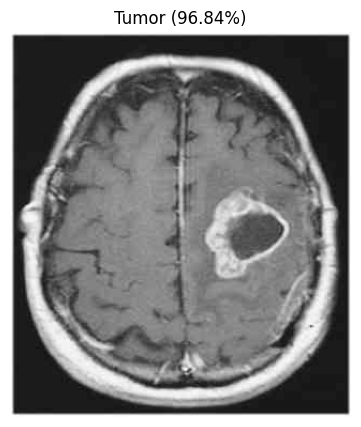

In [57]:
img_path = os.path.join(
    val_yes,
    os.listdir(val_yes)[19]
)

# Open image and convert to RGB
img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')

# Resize image
img_resized = img.resize((224,224))

# Convert to NumPy array
img_array = np.array(
    img_resized,
    dtype=np.float32
)

print("Shape before preprocessing:",
      img_array.shape)

# MobileNetV2 preprocessing
img_array = (
    tf.keras.applications
    .mobilenet_v2
    .preprocess_input(img_array)
)

# Add batch dimension
img_array = np.expand_dims(
    img_array,
    axis=0
)

print("Shape after preprocessing:",
      img_array.shape)

# Prediction
pred = model.predict(
    img_array,
    verbose=0
)[0][0]

label = (
    "Tumor"
    if pred > 0.5
    else "No Tumor"
)

confidence = (
    pred if pred > 0.5
    else 1 - pred
)

plt.title(
    f"{label} ({confidence:.2%})"
)

plt.show()

In [ ]:
model.summary()

In [62]:
base_model = model.layers[0]

classifier = tf.keras.Sequential(
    model.layers[1:]
)

In [63]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer(
        "out_relu"
    ).output
)

In [64]:
img_path = os.path.join(
    val_yes,
    os.listdir(val_yes)[19]
)

img = Image.open(
    img_path
).convert("RGB")

img = img.resize(
    (224,224)
)

img_array = np.array(
    img,
    dtype=np.float32
)

img_array = (
    tf.keras.applications
    .mobilenet_v2
    .preprocess_input(
        img_array
    )
)

img_array = np.expand_dims(
    img_array,
    axis=0
)

In [65]:
def make_gradcam_heatmap(
        img_array,
        grad_model,
        classifier):

    with tf.GradientTape() as tape:

        conv_outputs = grad_model(
            img_array
        )

        tape.watch(
            conv_outputs
        )

        predictions = classifier(
            conv_outputs
        )

        loss = predictions[:,0]

    grads = tape.gradient(
        loss,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(
            heatmap
        ) + 1e-8
    )

    return heatmap.numpy()

In [66]:
heatmap = make_gradcam_heatmap(
    img_array,
    grad_model,
    classifier
)

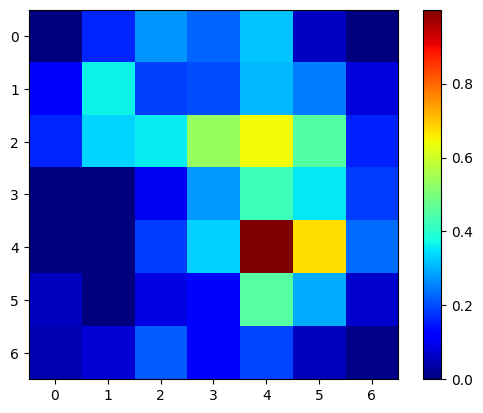

In [67]:
plt.imshow(
    heatmap,
    cmap='jet'
)
plt.colorbar()
plt.show()

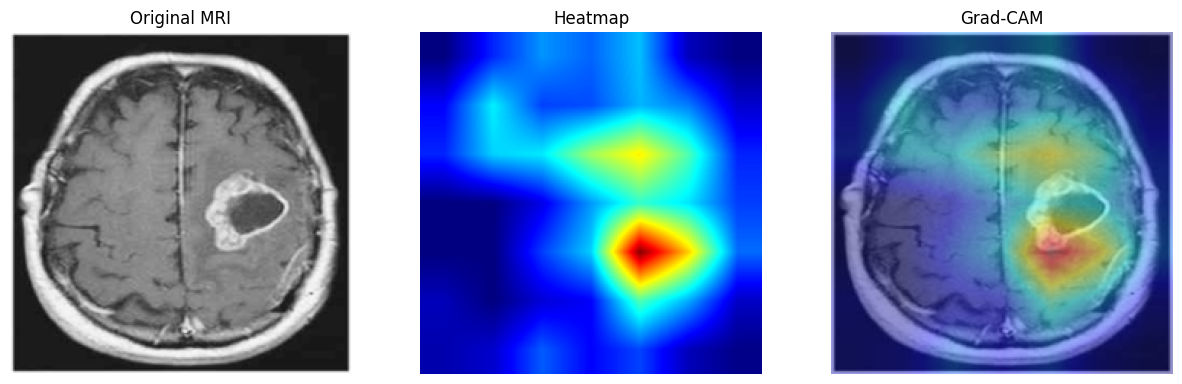

In [68]:
import cv2

original_img = Image.open(
    img_path
).convert("RGB")

original_img = original_img.resize(
    (224,224)
)

original_img = np.array(
    original_img
)

heatmap = cv2.resize(
    heatmap,
    (224,224)
)

heatmap = np.uint8(
    255 * heatmap
)

heatmap_color = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original_img)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(
    heatmap_color[:,:,::-1]
)
plt.title("Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(
    superimposed_img[:,:,::-1]
)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()